# Experiment: MoNuSAC Annotation QC and 40x to 20x Rescaling

Objective:
- Visualize exported MoNuSAC RGB patches with their merged instance-label masks overlaid.
- Downsample a 40x patch to 20x, update the instance mask with a label-aware resize, and inspect the new overlay.

Notes:
- Run this notebook from `scripts/benchmarking/` when possible.
- By default it looks for `../../data/Monusac/`, but you can override the path in the configuration cell.
- The resize path uses area-style downsampling for the RGB patch and per-instance binary downsampling for the label mask so instance IDs are never interpolated together.


In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path("/share/lab_teng/trainee/tusharsingh/cell-seg/scripts/benchmarking")
if not (NOTEBOOK_DIR / 'monusac_visualization_utils.py').exists():
    candidate = (NOTEBOOK_DIR / 'scripts' / 'benchmarking').resolve()
    if candidate.exists() and (candidate / 'monusac_visualization_utils.py').exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from monusac_visualization_utils import (
    DEFAULT_MIN_INSTANCE_FRACTION,
    default_monusac_root,
    load_export_index,
    load_sample_arrays,
    plot_resize_comparison,
    plot_sample_triptych,
    resolve_monusac_root,
    rescale_patch_and_mask,
    select_sample,
)

PROJECT_ROOT = (NOTEBOOK_DIR / '../..').resolve()
DEFAULT_DATA_ROOT = default_monusac_root(search_from=NOTEBOOK_DIR)

print(f'Notebook directory: {NOTEBOOK_DIR}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Default MoNuSAC root: {DEFAULT_DATA_ROOT}')


Notebook directory: /share/lab_teng/trainee/tusharsingh/cell-seg/scripts/benchmarking
Project root: /share/lab_teng/trainee/tusharsingh/cell-seg
Default MoNuSAC root: /share/lab_teng/trainee/tusharsingh/cell-seg/data/Monusac


## Sample Selection

Use `UNIQUE_ID` if you already know the exact exported patch you want to inspect.
Otherwise, set `FOLDER`, optionally filter by `TISSUE`, and choose a `ROW_INDEX` from the preview table.


In [5]:
DATA_ROOT = resolve_monusac_root(search_from=NOTEBOOK_DIR)
FOLDER = 'all_merged'   # or 'kidney_only'
TISSUE = None           # e.g. 'Kidney'
UNIQUE_ID = None        # e.g. '0009_train_0009_TCGA-EV-5903_kidney'
ROW_INDEX = 0

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'MoNuSAC root not found at {DATA_ROOT}. '                'Edit DATA_ROOT or set the MONUSAC_ROOT environment variable first.'
    )

export_index = load_export_index(DATA_ROOT)
filtered_preview = export_index.copy()

if 'folder' in filtered_preview.columns and FOLDER:
    filtered_preview = filtered_preview.loc[filtered_preview['folder'].eq(FOLDER)]
if TISSUE is not None and 'tissue' in filtered_preview.columns:
    filtered_preview = filtered_preview.loc[
        filtered_preview['tissue'].astype(str).str.casefold().eq(TISSUE.casefold())
    ]
if UNIQUE_ID is not None:
    filtered_preview = filtered_preview.loc[filtered_preview['unique_id'].astype(str).eq(UNIQUE_ID)]

preview_columns = [
    column
    for column in ['unique_id', 'tissue', 'patient', 'source_split', 'source_index', 'num_instances', 'folder']
    if column in filtered_preview.columns
]

print(f'Using data root: {DATA_ROOT}')
print(f'Total indexed samples: {len(export_index)}')
print(f'Samples after filters: {len(filtered_preview)}')

filtered_preview.loc[:, preview_columns].head(10)


Using data root: /share/lab_teng/trainee/tusharsingh/cell-seg/data/Monusac
Total indexed samples: 396
Samples after filters: 310


,unique_id,tissue,patient,source_split,source_index,num_instances,folder
0,0000_train_0000_TCGA-73-4668_lung,Lung,TCGA-73-4668,train,0,17,all_merged
1,0001_train_0001_TCGA-73-4668_lung,Lung,TCGA-73-4668,train,1,5,all_merged
2,0002_train_0002_TCGA-73-4668_lung,Lung,TCGA-73-4668,train,2,302,all_merged
3,0003_train_0003_TCGA-73-4668_lung,Lung,TCGA-73-4668,train,3,203,all_merged
4,0004_train_0004_TCGA-55-1594_lung,Lung,TCGA-55-1594,train,4,251,all_merged
5,0005_train_0005_TCGA-55-1594_lung,Lung,TCGA-55-1594,train,5,36,all_merged
6,0006_train_0006_TCGA-55-1594_lung,Lung,TCGA-55-1594,train,6,300,all_merged
7,0007_train_0007_TCGA-55-1594_lung,Lung,TCGA-55-1594,train,7,64,all_merged
8,0008_train_0008_TCGA-55-1594_lung,Lung,TCGA-55-1594,train,8,21,all_merged
9,0009_train_0009_TCGA-EV-5903_kidney,Kidney,TCGA-EV-5903,train,9,337,all_merged


In [6]:
sample_row = select_sample(
    export_index,
    unique_id=UNIQUE_ID,
    tissue=TISSUE,
    folder=FOLDER,
    row_index=ROW_INDEX,
)
image, mask = load_sample_arrays(sample_row, data_root=DATA_ROOT)

mask_labels = np.unique(mask)
original_instance_count = int(mask_labels[mask_labels > 0].size)

print(f"Loaded sample: {sample_row['unique_id']}")
print(f'Image shape: {image.shape}')
print(f'Mask shape: {mask.shape}')
print(f'Instance count: {original_instance_count}')

pd.Series(sample_row)


Loaded sample: 0000_train_0000_TCGA-73-4668_lung
Image shape: (591, 778, 3)
Mask shape: (591, 778)
Instance count: 17


unique_id                         0000_train_0000_TCGA-73-4668_lung
patient                                                TCGA-73-4668
tissue                                                         Lung
source_split                                                  train
source_index                                                      0
num_instances                                                    17
overlap_pixels                                                    0
image_path        /share/lab_teng/trainee/tusharsingh/cell-seg/d...
mask_path         /share/lab_teng/trainee/tusharsingh/cell-seg/d...
folder                                                   all_merged
Name: 0, dtype: object

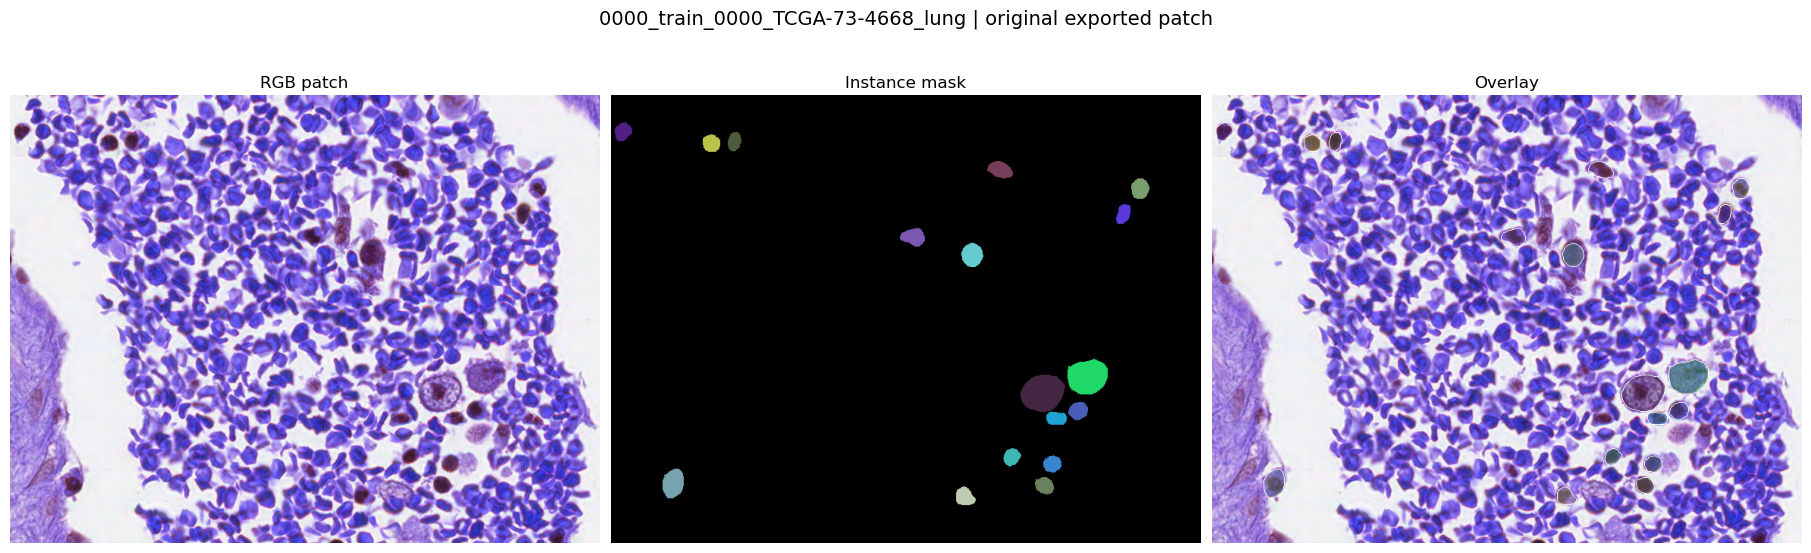

In [7]:
_ = plot_sample_triptych(
    image,
    mask,
    title=f"{sample_row['unique_id']} | original exported patch",
)


## 40x to 20x Rescaling

The RGB patch is downsampled with Pillow's `BOX` resampler, which behaves like area averaging for shrink operations.
The instance mask is resized one label at a time:
- convert each instance to a binary mask,
- downsample the binary mask with the same area-style resampler,
- assign each target pixel to the label with the strongest fractional support above `MIN_INSTANCE_FRACTION`.

This is safer than resizing the integer label map directly because label IDs are categorical, not continuous values.


In [8]:
SOURCE_MAGNIFICATION = 40
TARGET_MAGNIFICATION = 20
MIN_INSTANCE_FRACTION = DEFAULT_MIN_INSTANCE_FRACTION  # 0.25 keeps small nuclei from disappearing too aggressively.

image_20x, mask_20x, resize_meta = rescale_patch_and_mask(
    image=image,
    instance_mask=mask,
    source_magnification=SOURCE_MAGNIFICATION,
    target_magnification=TARGET_MAGNIFICATION,
    min_instance_fraction=MIN_INSTANCE_FRACTION,
)

pd.Series(resize_meta)


source_shape               (591, 778)
target_shape               (296, 389)
source_magnification             40.0
target_magnification             20.0
scale_factor                      0.5
min_instance_fraction            0.25
original_instance_count            17
resized_instance_count             17
dropped_instance_count              0
dropped_instance_labels            []
dtype: object

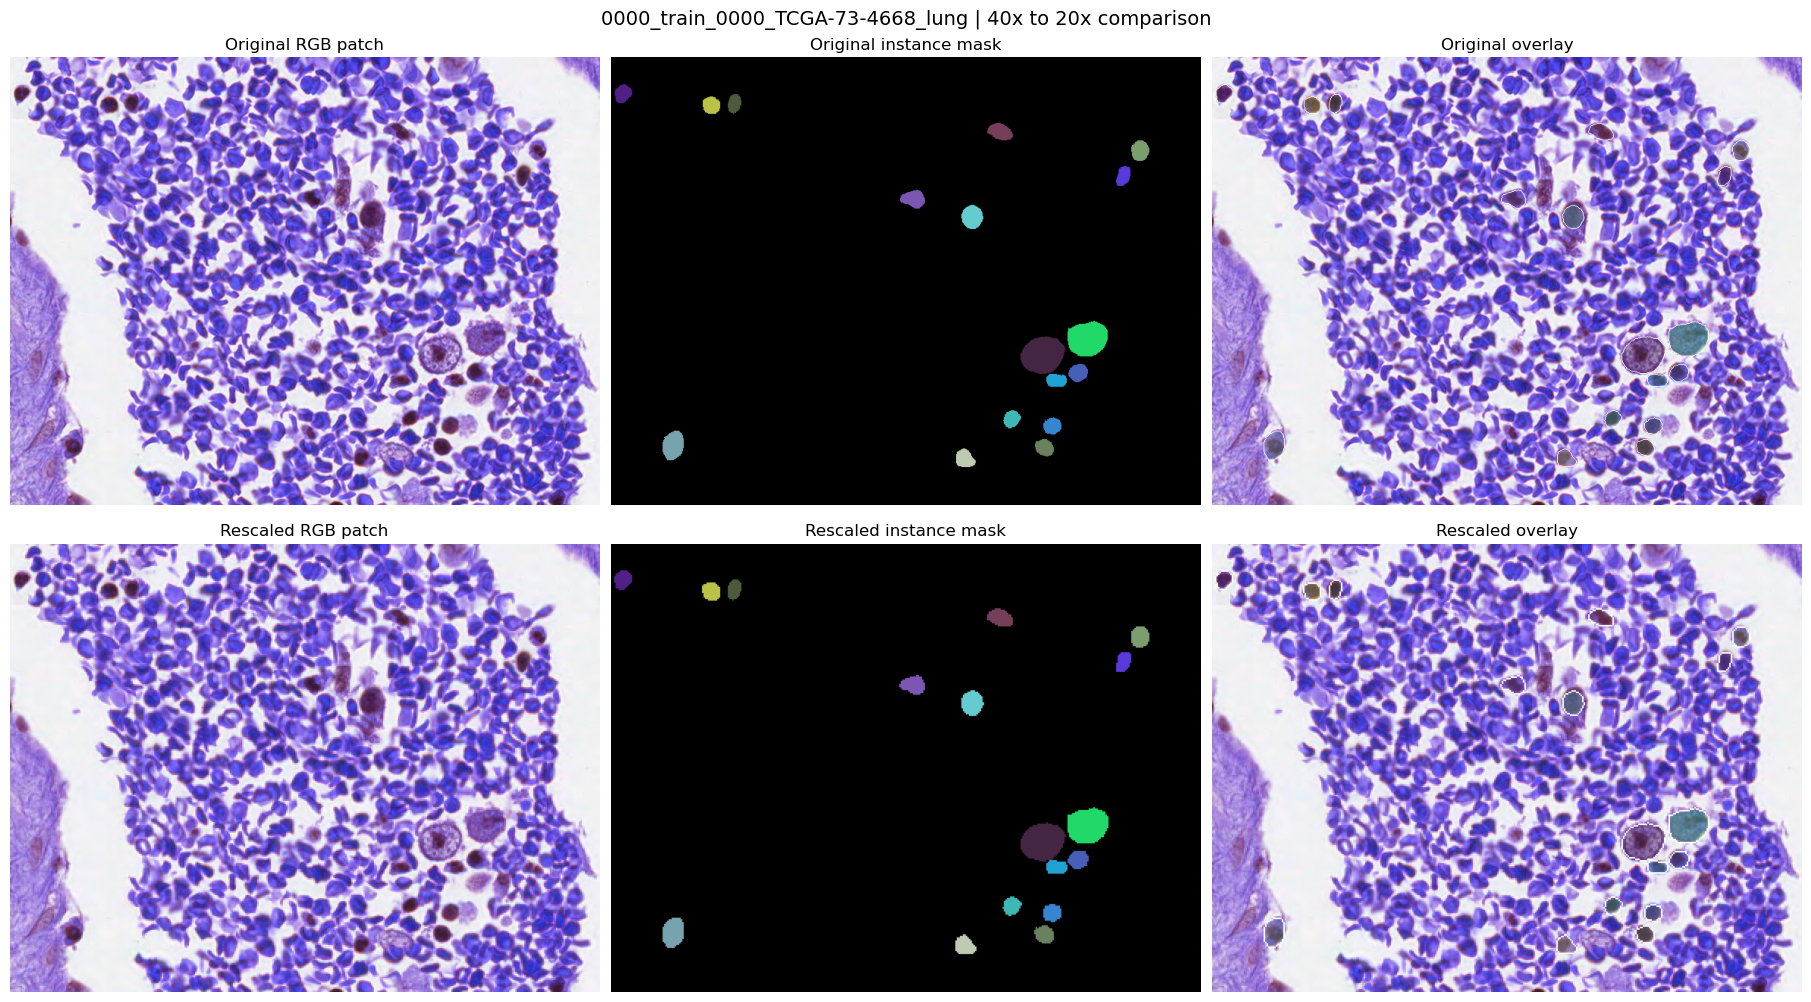

In [9]:
_ = plot_resize_comparison(
    original_image=image,
    original_mask=mask,
    resized_image=image_20x,
    resized_mask=mask_20x,
    title=f"{sample_row['unique_id']} | {SOURCE_MAGNIFICATION}x to {TARGET_MAGNIFICATION}x comparison",
)


## Minimal Reuse Snippet

Copy the call below into another notebook or preprocessing script if you want the same 40x to 20x conversion logic elsewhere in the project.


In [ ]:
rescaled_image, rescaled_mask, resize_metadata = rescale_patch_and_mask(
    image=image,
    instance_mask=mask,
    source_magnification=40,
    target_magnification=20,
    min_instance_fraction=0.25,
)
